# Parse History Trajectory

Parses a trajectory JSON generated with `--track-history`.
Works with both single-coin and two-coin environments.
Coin positions and collection events are inferred directly from the grid state (watching 'C' symbols disappear).

In [ ]:
import json
from pathlib import Path

TRAJECTORY_PATH = Path(
    "../data/two_coin_tests/collect_one_low_with_history/"
    "two_coin_collect_one_batch_test_1/"
    "together_ai_openai_gpt-oss-20b_size9_comp0.0_grid0_twocoin_low_traj0.json"
)

with open(TRAJECTORY_PATH) as f:
    traj = json.load(f)

grid_params  = traj["grid_params"]
model_params = traj["model_params"]
steps        = traj["steps"]

print(f"Model:    {model_params['model_id']}")
print(f"Template: {model_params.get('template_name', 'n/a')}")
print(f"Grid:     {grid_params['grid_width']}x{grid_params['grid_height']}, complexity={grid_params['grid_complexity']}")
print(f"A* dist:  {grid_params.get('astar_distance')}")
print(f"Steps:    {len(steps)}")

Model:    openai/gpt-oss-20b
Template: n/a
Grid:     9x9, complexity=0.0
A* dist:  6
Steps:    30


## Prompt template

In [13]:
print(traj["prompt"]["prompt_template"])

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2026-07-02

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|># Instructions

You are controlling an agent in a grid-based environment with full observability. The agent can move in four directions: up, down, left, and right. The environment contains walls, open spaces, a goal location, and two coins. The following symbols are used in the grid representation:

Legend:
---------------
#: Wall
_: Open Space (can be visited)
G: Goal
A: Current agent position
C: Coin (collectible item)
----------------

Your objective is to navigate from the current position (A) to the goal (G), collecting exactly ONE of the two coins (C) along the way. You should only step onto ONE coin cell before reaching the goal, you do not need to collect both — collecting one is sufficient. After collecti

## Grid-state parsing helpers

In [14]:
def find_symbol(grid_lines: list[str], symbol: str) -> tuple[int, int] | None:
    """Return (col, row) of first occurrence of `symbol`, or None."""
    for row_str in grid_lines:
        parts = row_str.split()
        if len(parts) < 2:
            continue
        try:
            row_idx = int(parts[0])
        except ValueError:
            continue  # header row
        for col_idx, cell in enumerate(parts[1:]):
            if cell == symbol:
                return (col_idx, row_idx)
    return None


def find_all_symbols(grid_lines: list[str], symbol: str) -> list[tuple[int, int]]:
    """Return all (col, row) positions of `symbol`."""
    positions = []
    for row_str in grid_lines:
        parts = row_str.split()
        if len(parts) < 2:
            continue
        try:
            row_idx = int(parts[0])
        except ValueError:
            continue
        for col_idx, cell in enumerate(parts[1:]):
            if cell == symbol:
                positions.append((col_idx, row_idx))
    return positions


def count_coins(grid_lines: list[str]) -> int:
    return len(find_all_symbols(grid_lines, "C"))


# Infer positions from step 0 grid state
initial_coins = find_all_symbols(steps[0]["grid_state"], "C")
goal_pos      = find_symbol(steps[0]["grid_state"], "G")
start_pos     = find_symbol(steps[0]["grid_state"], "A")

print(f"Coin positions (step 0): {initial_coins}")
print(f"Goal position:           {goal_pos}")
print(f"Agent start:             {start_pos}")

Coin positions (step 0): [(1, 5), (7, 7)]
Goal position:           (5, 6)
Agent start:             (4, 1)


## Reconstruct per-step state

`coins_collected` is not stored per step in the two-coin format, so we derive it by watching when 'C' symbols disappear from the grid state between consecutive steps.

The history shown to the LLM at step N is `(position, action, cumulative_coins)` entries from steps 0..N-1.

In [15]:
step_records    = []
history_shown   = []   # history_shown[i] = what LLM received at step i
running_history = []
cumulative      = 0
prev_count      = count_coins(steps[0]["grid_state"])

for step in steps:
    pos    = find_symbol(step["grid_state"], "A")
    action = step["agent_action"]
    n_coins = count_coins(step["grid_state"])

    history_shown.append(list(running_history))        # snapshot before this action
    running_history.append((pos, action, cumulative))  # record what happened

    # Coin count drops on the step AFTER collection, so check vs previous step
    collected = max(0, prev_count - n_coins)
    cumulative += collected
    prev_count = n_coins

    step_records.append({
        "pos":              pos,
        "action":           action,
        "coins_in_grid":    n_coins,
        "collected_here":   collected > 0,
        "cumulative_coins": cumulative,
        "history_len":      len(history_shown[-1]),
        "output_n_tokens":  step["output_n_tokens"],
    })

coin_steps = [i for i, r in enumerate(step_records) if r["collected_here"]]
print(f"Total coins collected: {cumulative} / {len(initial_coins)}")
print(f"Collection at steps:   {coin_steps}")
print(f"History shown at step 0: {history_shown[0]}  (should be empty)")
print(f"History shown at step 2: {history_shown[2]}")

Total coins collected: 2 / 2
Collection at steps:   [9, 25]
History shown at step 0: []  (should be empty)
History shown at step 2: [((4, 1), 'DOWN', 0), ((4, 2), 'DOWN', 0)]


## Trajectory summary table

In [16]:
import pandas as pd

df = pd.DataFrame(step_records)
df.index.name = "step"
print(df.to_string())

         pos action  coins_in_grid  collected_here  cumulative_coins  history_len  output_n_tokens
step                                                                                              
0     (4, 1)   DOWN              2           False                 0            0              275
1     (4, 2)   DOWN              2           False                 0            1              180
2     (4, 3)   DOWN              2           False                 0            2              227
3     (4, 4)   DOWN              2           False                 0            3              138
4     (4, 5)   DOWN              2           False                 0            4              248
5     (4, 6)   DOWN              2           False                 0            5              650
6     (4, 7)  RIGHT              2           False                 0            6              178
7     (5, 7)  RIGHT              2           False                 0            7              104
8     (6, 

## Step-by-step inspection

Grid state, reconstructed history shown to the LLM, and the first 400 chars of its output.

In [17]:
N_STEPS_TO_SHOW = 50  # change to len(steps) for all

for i, (step, rec) in enumerate(zip(steps[:N_STEPS_TO_SHOW], step_records[:N_STEPS_TO_SHOW])):
    print("=" * 65)
    print(f"STEP {i}  |  action={rec['action']:<6}  |  coins_in_grid={rec['coins_in_grid']}  |  collected={rec['collected_here']}")
    print()

    for line in step["grid_state"]:
        print(" ", line)
    print()

    hist = history_shown[i]
    if hist:
        print("History shown to LLM:")
        for pos, act, coins in hist:
            print(f"  ({pos[0]}, {pos[1]}): {act}, coins collected: {coins}")
    else:
        print("History shown to LLM: (none — first step)")
    print()

    print("LLM output (truncated):")
    print(" ", step["output_text"][:400].replace("\n", "\n  "))
    print()

STEP 0  |  action=DOWN    |  coins_in_grid=2  |  collected=False

    0 1 2 3 4 5 6 7 8 
  0 # # # # # # # # # 
  1 # _ _ _ A _ _ _ # 
  2 # _ _ _ _ _ _ _ # 
  3 # _ _ _ _ _ _ _ # 
  4 # _ _ _ _ _ _ _ # 
  5 # C _ _ _ _ _ _ # 
  6 # _ _ _ _ G _ _ # 
  7 # _ _ _ _ _ _ C # 
  8 # # # # # # # # # 

History shown to LLM: (none — first step)

LLM output (truncated):
  <|channel|>analysis<|message|>We need move to collect one coin then goal. Start at (1,4). Coins at (1,5?) Wait grid: row5 col1? Row5 index: row5 has C at col1. Also row7 col7? row7 col7? row7 has C at col7. Goal at row6 col5. Path: from (1,4) go down to row5 col4, then left to col1 to collect first coin. Then go up to goal. Let's compute moves: from (1,4) DOWN to (2,4), DOWN to (3,4), DOWN to (4,4

STEP 1  |  action=DOWN    |  coins_in_grid=2  |  collected=False

    0 1 2 3 4 5 6 7 8 
  0 # # # # # # # # # 
  1 # _ _ _ _ _ _ _ # 
  2 # _ _ _ A _ _ _ # 
  3 # _ _ _ _ _ _ _ # 
  4 # _ _ _ _ _ _ _ # 
  5 # C _ _ _ _ _ _ # 
  6 #

## Token logprobs on a chosen step

In [18]:
STEP_TO_INSPECT = 2

step = steps[STEP_TO_INSPECT]
print(f"Step {STEP_TO_INSPECT} — action: {step['agent_action']}")
print()

for tok in step["output_tokens"]:
    probs = tok.get("probabilities", {})
    if not probs:
        continue
    top = sorted(probs.items(), key=lambda x: -x[1])
    print(f"  {repr(tok['token']):<28}  top-3: {top[:3]}")

Step 2 — action: DOWN

  'We'                          top-3: [('We', 0.9656), ('Need', 0.0159), ('Agent', 0.0159)]
  'Ġneed'                       top-3: [(' need', 0.8427), (' are', 0.1413), (' have', 0.0139)]
  'Ġpath'                       top-3: [(' to', 0.5009), (' move', 0.2932), (' path', 0.12)]
  'Ġfrom'                       top-3: [(' from', 0.9138), (' to', 0.0439), (':', 0.0367)]
  'ĠA'                          top-3: [(' A', 0.9846), (' agent', 0.0079), (' (', 0.0066)]
  'Ġat'                         top-3: [(' at', 0.9985), (' (', 0.0011), ('(', 0.0003)]
  'Ġ('                          top-3: [(' (', 0.9933), (' row', 0.0067), ('?', 0.0)]
  '3'                           top-3: [('4', 0.5874), ('3', 0.411), ('1', 0.0011)]
  ','                           top-3: [(',', 1.0), ('?', 0.0), ('?,', 0.0)]
  '4'                           top-3: [('4', 0.9997), ('3', 0.0002), ('5', 0.0001)]
  ')'                           top-3: [(').', 0.4421), (')', 0.4421), ('?)', 0.0886)]
  'Ġt

## Trajectory path plot

Reuses rendering from `analysis/plot_trajectories_two_coins.py`.

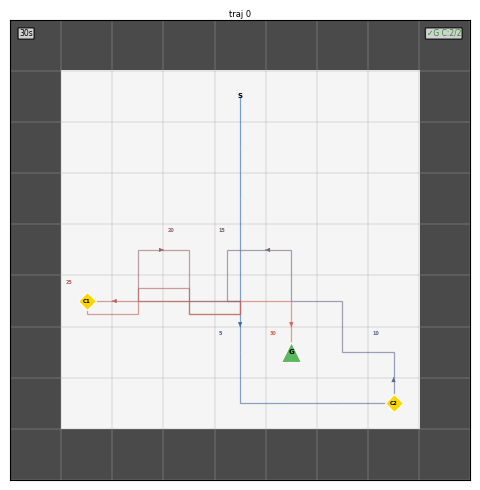

Reached goal: True  |  Coins collected: 2/2


In [19]:
import sys
sys.path.insert(0, "../analysis")

from plot_trajectories_two_coins import (
    load_layout, build_path, find_coin_collection_steps, detect_reached_goal, draw_panel
)
import matplotlib.pyplot as plt

# Find companion layout file in same directory
layout_path = next(TRAJECTORY_PATH.parent.glob("*_layout.json"))
layout = load_layout(layout_path)

path         = build_path(steps)
cc1, cc2     = find_coin_collection_steps(steps)
coins_col    = (cc1 is not None) + (cc2 is not None)
reached_goal = detect_reached_goal(steps, layout["goal_pos"])

fig, ax = plt.subplots(figsize=(5, 5))
draw_panel(ax, layout, path, traj_id=0,
           coins_collected=coins_col, reached_goal=reached_goal,
           cc_step_1=cc1, cc_step_2=cc2)
plt.tight_layout()
plt.show()

print(f"Reached goal: {reached_goal}  |  Coins collected: {coins_col}/{len(initial_coins)}")